In [1]:
import gwaslab as gl
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load gwas data

In [81]:
import pandas as pd
import gzip

file_path = "../data/susie/gwas/21001_raw.gwas.imputed_v3.both_sexes.tsv.bgz"
with gzip.open(file_path, 'rt') as f:
    gwas_data_df = pd.read_csv(f, sep='\t') 


In [82]:
gwas_data_df

,variant,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,pval
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342
...,...,...,...,...,...,...,...,...,...,...,...
13791462,X:154929412:C:T,T,2.454730e-01,False,359983,176732.000000,4.837480e+06,-0.016260,0.010723,-1.516370,0.129427
13791463,X:154929637:CT:C,C,2.297260e-01,False,359983,165395.000000,4.525550e+06,-0.027098,0.011190,-2.421510,0.015456
13791464,X:154929952:CAA:C,C,2.394300e-01,False,359983,172381.000000,4.717910e+06,-0.020494,0.011278,-1.817100,0.069202
13791465,X:154930230:A:G,G,2.458870e-01,False,359983,177030.000000,4.845680e+06,-0.016347,0.010721,-1.524700,0.127334


## Data Processing 

In [83]:
gwas_data_df['CHR'] = gwas_data_df['variant'].str.split(':').str[0]
gwas_data_df['POS'] = gwas_data_df['variant'].str.split(':').str[1]
gwas_data_df['A2'] = gwas_data_df['variant'].str.split(':').str[2]
gwas_data_df['A1'] = gwas_data_df['variant'].str.split(':').str[3]


In [84]:
gwas_data_df.head()

,variant,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,pval,CHR,POS,A2,A1
0,1:15791:C:T,T,5.446880e-09,True,359983,0.003922,1.238950e-01,894.616000,1204.870000,0.742499,0.457786,1,15791,C,T
1,1:69487:G:A,A,5.768250e-06,True,359983,4.152940,1.035150e+02,-2.715450,2.360060,-1.150590,0.249902,1,69487,G,A
2,1:69569:T:C,C,1.878960e-04,True,359983,135.278000,3.644560e+03,-0.484284,0.423462,-1.143630,0.252778,1,69569,T,C
3,1:139853:C:T,T,5.681100e-06,True,359983,4.090200,1.018400e+02,-2.703560,2.360130,-1.145510,0.251997,1,139853,C,T
4,1:692794:CA:C,C,1.105900e-01,False,359983,79621.100000,2.179000e+06,-0.016436,0.019585,-0.839228,0.401342,1,692794,CA,C


## Minor Allele Frequency Filtering 

In [85]:
gwas_data_df=gwas_data_df.rename(columns={'variant':'SNPID', 'pval':'P'})
gwas_data_df= gwas_data_df[gwas_data_df['minor_AF'] > 0.05]
gwas_data_df = gwas_data_df[~gwas_data_df['SNPID'].str.startswith('X:')]


In [86]:
gwas_data_df.shape

(6746855, 15)

In [87]:
gwas_data_df.to_csv("../data/susie/processed_raw_data/gwas_snps.csv", index=False)

## Extract Most significant variant from cojo snd Define region around the most significant SNP from the gwas data

In [88]:
import pandas as pd
cojo_results_df = pd.read_csv("../data/susie/cojo/all_chr/all_chr_cojo.jma.cojo", delim_whitespace=True)
cojo_results_df.head()


/tmp/ipykernel_2791549/3749684294.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cojo_results_df = pd.read_csv("../data/susie/cojo/all_chr/all_chr_cojo.jma.cojo", delim_whitespace=True)


,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
0,1,1:1590521:G:A,1590521,A,0.265231,-0.100267,0.012675,2.562560e-15,357785,0.258986,-0.126050,0.012930,1.873560e-22,0.003818
1,1,1:1866376:G:A,1866376,A,0.496263,0.067971,0.011644,5.306640e-09,330513,0.516374,0.074590,0.011663,1.598820e-10,0.034421
2,1,1:2427712:C:T,2427712,T,0.455874,-0.070197,0.011267,4.660130e-10,355744,0.326478,-0.082146,0.011438,6.870130e-13,-0.099375
3,1,1:6669970:C:G,6669970,G,0.355676,0.064158,0.011662,3.767190e-08,359447,0.358027,0.075553,0.011830,1.696020e-10,0.000000
4,1,1:23353906:CT:C,23353906,C,0.167309,0.085668,0.014989,1.094920e-08,357912,0.296126,0.083185,0.014994,2.891550e-08,0.023570


In [89]:
cojo_results_df.shape

(506, 14)

In [90]:
most_significant_snp = cojo_results_df.sort_values(by='p').head(1)
most_significant_snp

,Chr,SNP,bp,refA,freq,b,se,p,n,freq_geno,bJ,bJ_se,pJ,LD_r
416,16,16:53828066:C:T,53828066,T,0.392165,0.349002,0.011405,1.224550e-205,360397,0.221446,-0.481828,0.030674,1.336110e-55,0.821113


In [91]:
window_size = 500000  
output_dir = "../data/susie/ALL_chr/"  


cojo_results_df["bp"] = cojo_results_df["bp"].astype(int)
cojo_results_df["Chr"] = cojo_results_df["Chr"].astype(str)  
gwas_data_df["POS"] = gwas_data_df["POS"].astype(int)
gwas_data_df["CHR"] = gwas_data_df["CHR"].astype(str) 


target_pos = 53828066
target_row = cojo_results_df[cojo_results_df["bp"] == target_pos]

if not target_row.empty:
    row = target_row.iloc[0]
    chrom = row["Chr"]  
    pos = row["bp"]  
    start_pos = pos - window_size
    end_pos = pos + window_size

    df_region = gwas_data_df[
        (gwas_data_df["CHR"] == str(chrom)) & 
        (gwas_data_df["POS"] >= start_pos) & 
        (gwas_data_df["POS"] <= end_pos)
    ]
    
    output_file = f"{output_dir}/cojo_chr{chrom}_pos{pos}_gwas_snps.txt"
    df_region.to_csv(output_file, sep="\t", index=False)

    print(f"Extracted {len(df_region)} SNPs for Chr{chrom} position {pos} and saved to {output_file}")
else:
    print(f"No row found in COJO results for position {target_pos}")


Extracted 2368 SNPs for Chr16 position 53828066 and saved to ../data/susie/ALL_chr//cojo_chr16_pos53828066_gwas_snps.txt


In [92]:
import pandas as pd
gwas_snps_df=pd.read_csv("../data/susie/processed_raw_data/gwas_snps.csv", delim_whitespace=False)
gwas_snps_df

/tmp/ipykernel_2791549/3516213101.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  gwas_snps_df=pd.read_csv("../data/susie/processed_raw_data/gwas_snps.csv", delim_whitespace=False)


,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS,A2,A1
0,1:692794:CA:C,C,0.110590,False,359983,79621.1,2179000.0,-0.016436,0.019585,-0.839228,0.401342,1,692794,CA,C
1,1:693731:A:G,G,0.115767,False,359983,83348.0,2281760.0,-0.004255,0.018507,-0.229918,0.818155,1,693731,A,G
2,1:707522:G:C,C,0.097255,False,359983,70020.6,1916410.0,-0.010428,0.020804,-0.501258,0.616190,1,707522,G,C
3,1:730087:T:C,C,0.056424,False,359983,40623.1,1110650.0,-0.047388,0.025783,-1.837930,0.066074,1,730087,T,C
4,1:731718:T:C,C,0.121670,False,359983,87598.4,2397990.0,-0.005842,0.017552,-0.332853,0.739246,1,731718,T,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6746850,22:51229717:A:T,T,0.296108,False,359983,213188.0,5841590.0,0.017674,0.013538,1.305480,0.191730,22,51229717,A,T
6746851,22:51229805:T:C,C,0.072990,False,359983,52550.3,1439420.0,0.002137,0.021510,0.099339,0.920869,22,51229805,T,C
6746852,22:51231220:A:G,G,0.053686,False,359983,38652.4,1058770.0,0.008422,0.026450,0.318400,0.750181,22,51231220,A,G
6746853,22:51237063:T:C,C,0.299001,False,359983,215270.0,5898910.0,0.021242,0.013134,1.617330,0.105807,22,51237063,T,C


## Expanding the region of one independet snp identified by cojo for testing 

In [93]:
cojo_chr16_pos53828066_snp=pd.read_csv("../data/susie/ALL_chr/cojo_chr16_pos53828066_gwas_snps.txt", delim_whitespace=True)

/tmp/ipykernel_2791549/957361236.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cojo_chr16_pos53828066_snp=pd.read_csv("../data/susie/ALL_chr/cojo_chr16_pos53828066_gwas_snps.txt", delim_whitespace=True)


In [94]:
cojo_chr16_pos53828066_snp.shape

(2368, 15)

## RUN PLINK

In [109]:
!plink \
  --bfile "../data/susie/plink_binary_for_all_gwas_snps/merged_data" \
  --keep-allele-order \
  --r square \
  --extract ../data/susie/ALL_chr/cojo_chr16_pos53828066_gwas_snps.txt \
  --out ../data/susie/test_ld_nan/test_gwas_sig_locus_mt

!plink \
  --bfile "../data/susie/plink_binary_for_all_gwas_snps/merged_data" \
  --keep-allele-order \
  --r2 square \
  --extract ../data/susie/ALL_chr/cojo_chr16_pos53828066_gwas_snps.txt \
  --out ../data/susie/test_ld_nan/test_gwas_sig_locus_mt_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/susie/test_ld_nan/test_gwas_sig_locus_mt.log.
Options in effect:
  --bfile ../data/susie/plink_binary_for_all_gwas_snps/merged_data
  --extract ../data/susie/ALL_chr/cojo_chr16_pos53828066_gwas_snps.txt
  --keep-allele-order
  --out ../data/susie/test_ld_nan/test_gwas_sig_locus_mt
  --r square

257418 MB RAM detected; reserving 128709 MB for main workspace.


6145215 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
../data/susie/test_ld_nan/test_gwas_sig_locus_mt.nosex .
--extract: 2335 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done.
Total genotyping rate is 0.999976.
2335 variants and 503 people pass filters and QC.
Note: No phenotypes present.
--r square to ../data/susie/test_ld_nan/test_gwas_sig_locus_mt.ld ...
0% [processingwriting]        done.
PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/susie/test_ld_nan/test_gwas_sig_lo

## Finemapping

In [96]:

from rpy2.robjects.packages import importr
import rpy2.robjects as ro
import rpy2.robjects.numpy2ri as numpy2ri
import rpy2.robjects.pandas2ri as pandas2ri
import matplotlib.pyplot as plt
numpy2ri.activate()
pandas2ri.activate()

In [97]:
susieR = importr('susieR')

## Visualization of LD (Linkage Disequilibrium) Matrices

In [110]:
import pandas as pd
ld_r = pd.read_csv("../data/susie/test_ld_nan/test_gwas_sig_locus_mt.ld", sep="\t", header=None)
R_df = ld_r.values
ld2 = pd.read_csv("../data/susie/test_ld_nan/test_gwas_sig_locus_mt_r2.ld",sep="\t",header=None)
R_df2 = ld2.values
R_df.shape

(2335, 2335)

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

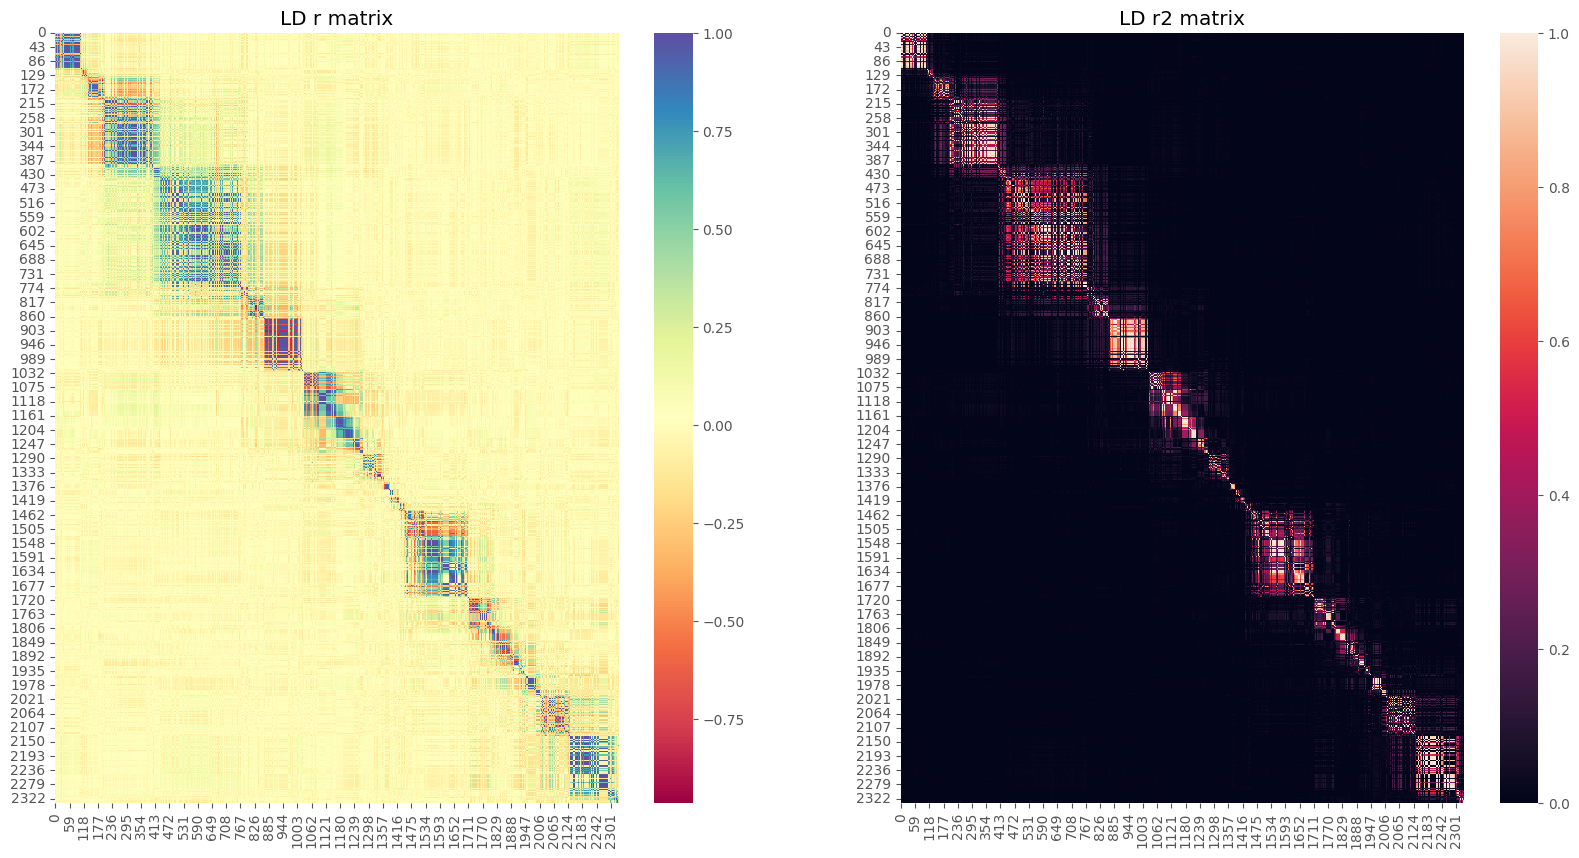

In [99]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=R_df,cmap="Spectral",ax=ax[0])
sns.heatmap(data=R_df2,ax=ax[1])
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")

In [100]:
print(type(R_df))  
print(R_df.shape) 
print(R_df[:5, :5]) 

<class 'numpy.ndarray'>
(2335, 2335)
[[ 1.       -0.465331 -0.27208   0.938837  1.      ]
 [-0.465331  1.       -0.263362 -0.43727  -0.465331]
 [-0.27208  -0.263362  1.       -0.246553 -0.27208 ]
 [ 0.938837 -0.43727  -0.246553  1.        0.938837]
 [ 1.       -0.465331 -0.27208   0.938837  1.      ]]


In [33]:
ro.r('set.seed(123)')
fit = susieR.susie_rss(
    bhat =cojo_chr16_pos53828066_snp["b"].values.reshape(len(cojo_chr16_pos53828066_snp), 1),
    shat = cojo_chr16_pos53828066_snp["se"].values.reshape(len(cojo_chr16_pos53828066_snp), 1),
    R = R_df,
    L = 10,
    n = 359983
)

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)

  The dimension of R (2335 x 2335) does not agree with expected (4718 x 4718)



RRuntimeError: Error in (function (z, R, n, bhat, shat, var_y, z_ld_weight = 0, estimate_residual_variance = FALSE,  : 
  The dimension of R (2335 x 2335) does not agree with expected (4718 x 4718)


## ISSUE:

From the plink result there are SNPS that are found in the gwas data(21001_raw.gwas.imputed_v3.both_sexes) which are missing from the vcf 1000 genomic population data. 

Inorder to see which snps are missing the method i used is

1.only store the SNP column that are found in the merged_data.bim(all chr plink binary files) to available_snps.txt
   `awk '{print $2}' ../data/susie/plink_binary_for_all_gwas_snps/merged_data.bim > newer_available_snps.txt`

2. extract SNPs that are not common from the avaliable_snps and from the current chr16_pos53828066_snps.txt

`grep -vFf newer_available_snps.txt ../data/susie/ALL_chr/cojo_chr16_pos53828066_gwas_snps.txt`
    SNPID   minor_allele    minor_AF        low_confidence_variant  n_complete_samples      AC      ytx     beta   se       tstat   P       CHR     POS     A2      A1
    16:53798630:C:CT        CT      0.115132        False   359983  82890.9 2260270.0       -0.155318       0.0176772       -8.78632        1.55203e-18     16      53798630        C       CT
    16:53799977:T:G G       0.421581        False   359983  303524.0        8371400.0       0.340303        0.0112735       30.1862 6.39588e-200    16      53799977        T       G
    16:53812783:TTTTG:T     T       0.390218        False   359983  280943.0        7751780.0       0.348645       0.01153  30.2382 1.33422e-200    16      53812783        TTTTG   T
    16:53820996:C:G G       0.392556        False   359983  282627.0        7799390.0       0.349687        0.0114009       30.6719 2.49515e-206    16      53820996        C       G

From the result there are total of `4` SNPs which are not included in the ld matrix.
The missing snps are also not found in the original vcf data before it is converted to plink binary files.

The current solution i used is to exclude these snps from the chr16_pos53828066_snps.txt so that to match the shape of the ld_matrix. 

In [120]:
missing_snps=pd.read_csv("missing_snps_all_gwas.txt", sep="\t")
missing_snps.shape

(33, 15)

In [ ]:
filtered_chr16_pos53828066_snps_ld_test = cojo_chr16_pos53828066_snp[~cojo_chr16_pos53828066_snp["SNPID"].isin(missing_snps["SNPID"])]
filtered_chr16_pos53828066_snps_ld_test.to_csv("../scripts/filtered_chr16_pos53828066_snps_ld_for_all_gwas.csv", index=False)

In [133]:
filtered_chr16_pos53828066_snps_ld_test.head(1)

,SNPID,minor_allele,minor_AF,low_confidence_variant,n_complete_samples,AC,ytx,beta,se,tstat,P,CHR,POS,A2,A1
0,16:53328787:T:C,C,0.322092,False,359983,231895.0,6350970.0,-0.001204,0.011914,-0.101056,0.919506,16,53328787,T,C


## Run finemapping with susieR

In [134]:
print(R_df.shape)
print(filtered_chr16_pos53828066_snps_ld_test["beta"].shape)
print(filtered_chr16_pos53828066_snps_ld_test["se"].shape)


(2335, 2335)
(2335,)
(2335,)


In [139]:
ro.r('set.seed(321)')
fit = susieR.susie_rss(
    bhat = filtered_chr16_pos53828066_snps_ld_test["beta"].values.reshape(len(R_df), 1),
    shat = filtered_chr16_pos53828066_snps_ld_test["se"].values.reshape(len(R_df), 1),
    R = R_df,
    L = 10,
    n = 359983,
    max_iter=500
)


 
                  Please check consistency between summary statistics and LD matrix.
                  See https://stephenslab.github.io/susieR/articles/susierss_diagnostic.html



## Extract credible sets and pip

In [140]:
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)
print(credible_sets)

$cs
$cs$L1
[1] 893

$cs$L2
[1] 906

$cs$L3
[1] 925

$cs$L5
[1] 918

$cs$L6
[1] 974

$cs$L7
[1] 929

$cs$L10
[1] 894


$purity
    min.abs.corr mean.abs.corr median.abs.corr
L1             1             1               1
L2             1             1               1
L3             1             1               1
L5             1             1               1
L6             1             1               1
L7             1             1               1
L10            1             1               1

$cs_index
[1]  1  2  3  5  6  7 10

$coverage
[1] 1 1 1 1 1 1 1

$requested_coverage
[1] 0.95




In [141]:

filtered_chr16_pos53828066_snps_ld_test["cs"] = 0
n_cs = len(susieR.susie_get_cs(fit, coverage = 0.95, min_abs_corr = 0.5, Xcorr = R_df)[0])
print(n_cs)
credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]

for i in range(n_cs):
    cs_index = credible_sets[i]
    filtered_chr16_pos53828066_snps_ld_test.loc[np.array(cs_index)-1, "cs"] = i + 1

filtered_chr16_pos53828066_snps_ld_test["pip"] = np.array(susieR.susie_get_pip(fit))

7


/tmp/ipykernel_2791549/427769197.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_chr16_pos53828066_snps_ld_test["cs"] = 0
/tmp/ipykernel_2791549/427769197.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_chr16_pos53828066_snps_ld_test["pip"] = np.array(susieR.susie_get_pip(fit))


## Create regional plot

/tmp/ipykernel_2791549/511045025.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_chr16_pos53828066_snps_ld_test[col_to_plot] = -np.log10(filtered_chr16_pos53828066_snps_ld_test["P"])


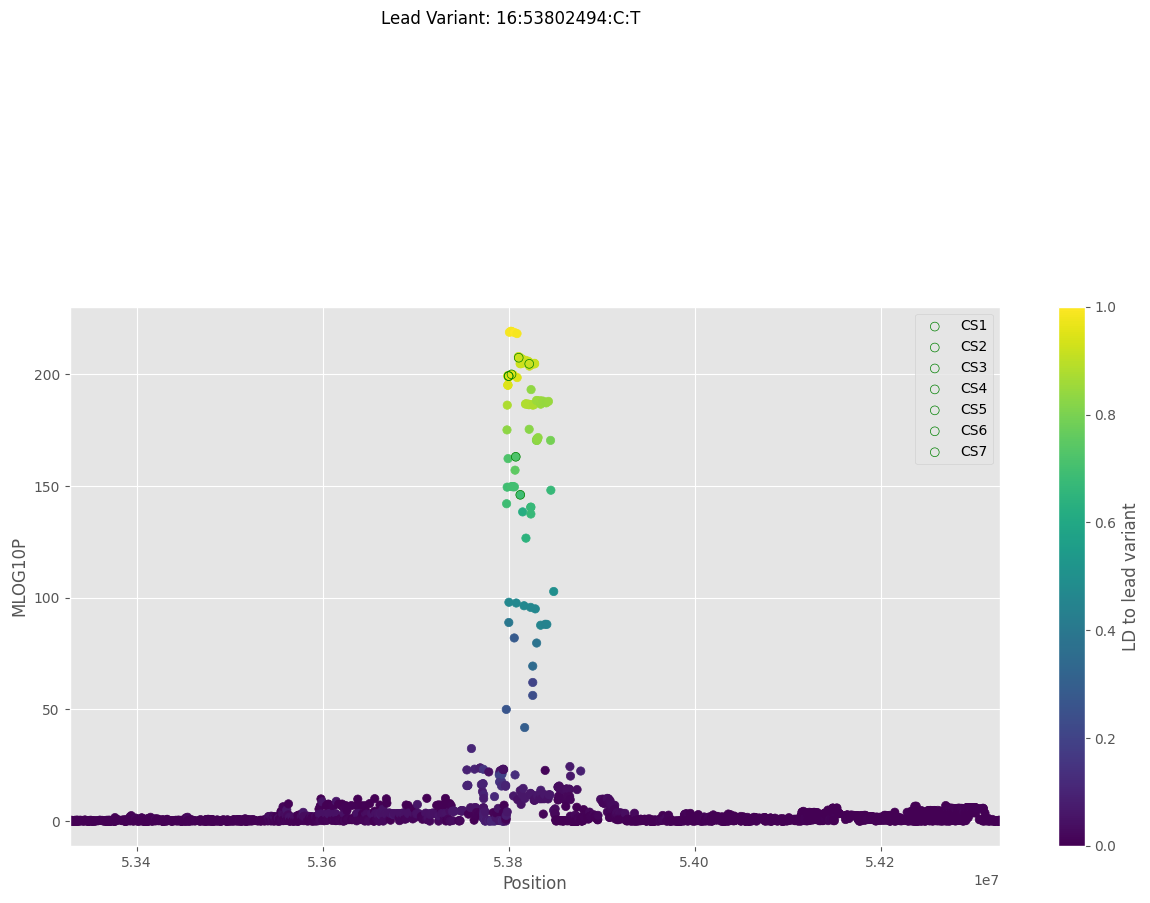

In [142]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "MLOG10P"
filtered_chr16_pos53828066_snps_ld_test[col_to_plot] = -np.log10(filtered_chr16_pos53828066_snps_ld_test["P"])

p = ax.scatter(
    filtered_chr16_pos53828066_snps_ld_test["POS"], 
    filtered_chr16_pos53828066_snps_ld_test[col_to_plot], 
    c=ld2[filtered_chr16_pos53828066_snps_ld_test["P"].idxmin()]
)

lead_x = filtered_chr16_pos53828066_snps_ld_test.loc[filtered_chr16_pos53828066_snps_ld_test["P"].idxmin(), "POS"]
lead_y = filtered_chr16_pos53828066_snps_ld_test.loc[filtered_chr16_pos53828066_snps_ld_test["P"].idxmin(), col_to_plot]

ax.annotate(
    f"Lead Variant: {filtered_chr16_pos53828066_snps_ld_test.loc[filtered_chr16_pos53828066_snps_ld_test['P'].idxmin(), 'SNPID']}", 
    (lead_x, lead_y), 
    textcoords="offset points", xytext=(0, lead_y + 2), ha='center', fontsize=12
)

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]

n_cs = len(credible_sets)
for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = filtered_chr16_pos53828066_snps_ld_test.loc[np.array(cs_index) - 1, "POS"]
    y = filtered_chr16_pos53828066_snps_ld_test.loc[np.array(cs_index) - 1, col_to_plot]
    
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolors="green", facecolors="none")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((53328066, 54328066))
plt.legend()
plt.show()


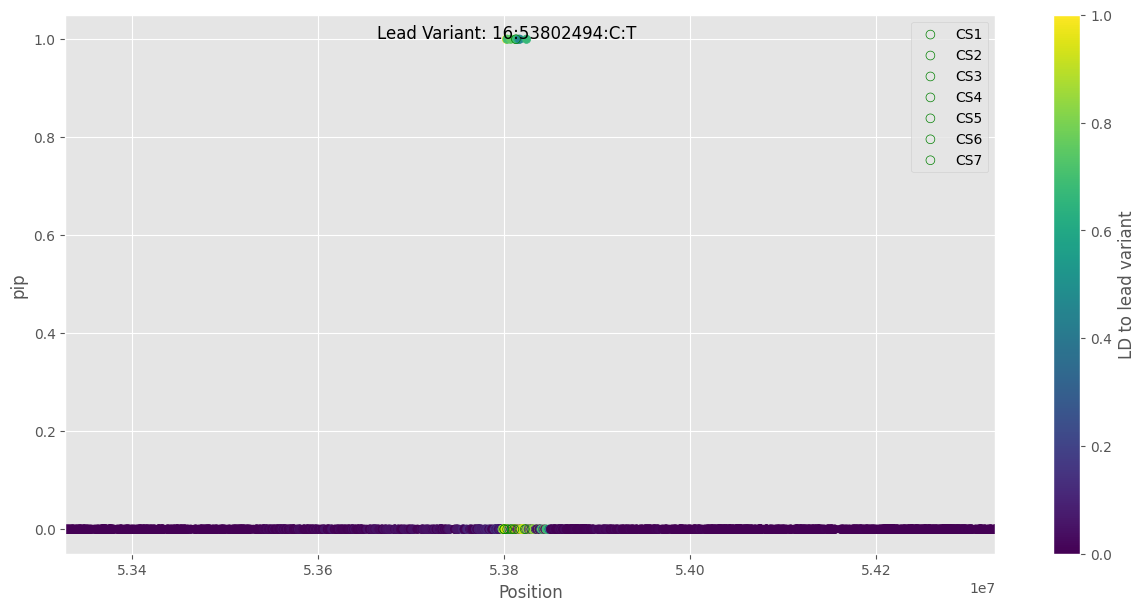

In [143]:
plt.style.use("ggplot")
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 7))

col_to_plot = "pip"
p = ax.scatter(
    filtered_chr16_pos53828066_snps_ld_test["POS"], 
    filtered_chr16_pos53828066_snps_ld_test[col_to_plot], 
    c=ld2[filtered_chr16_pos53828066_snps_ld_test["P"].idxmin()]
)

lead_x = filtered_chr16_pos53828066_snps_ld_test.loc[filtered_chr16_pos53828066_snps_ld_test["P"].idxmin(), "POS"]
lead_y = filtered_chr16_pos53828066_snps_ld_test.loc[filtered_chr16_pos53828066_snps_ld_test["P"].idxmin(), col_to_plot]

ax.annotate(
    f"Lead Variant: {filtered_chr16_pos53828066_snps_ld_test.loc[filtered_chr16_pos53828066_snps_ld_test['P'].idxmin(), 'SNPID']}", 
    (lead_x, lead_y), 
    textcoords="offset points", xytext=(0, lead_y + 0.02), ha='center', fontsize=12
)

credible_sets = susieR.susie_get_cs(fit, coverage=0.95, min_abs_corr=0.5, Xcorr=R_df)[0]
n_cs = len(credible_sets)

for i in range(n_cs):
    cs_index = credible_sets[i]
    pos = filtered_chr16_pos53828066_snps_ld_test.loc[np.array(cs_index) - 1, "POS"]
    y = filtered_chr16_pos53828066_snps_ld_test.loc[np.array(cs_index) - 1, col_to_plot]
    
    ax.scatter(pos, y, marker='o', s=40, label=f"CS{i+1}", edgecolors="green", facecolors="none")

plt.colorbar(p, label="LD to lead variant")
ax.set_xlabel("Position")
ax.set_ylabel(col_to_plot)
ax.set_xlim((53328066, 54328066))
# ax.set_ylim((0, 0.1))
plt.legend()
plt.show()


In [144]:
cs_index = np.array(credible_sets[0])
for i in range(1, n_cs):
    cs_index = np.concatenate((cs_index, np.array(credible_sets[i])), axis=0)
credible_snps = filtered_chr16_pos53828066_snps_ld_test.loc[cs_index - 1, :]

print(credible_snps)

               SNPID minor_allele  minor_AF  low_confidence_variant  \
892  16:53799985:T:A            A  0.421581                   False   
905  16:53803187:A:T            T  0.421813                   False   
924  16:53810943:C:T            T  0.393365                   False   
917  16:53807764:A:G            G  0.481500                   False   
973  16:53822239:A:G            G  0.392958                   False   
928  16:53812614:G:A            A  0.475000                   False   
893  16:53800200:C:T            T  0.421569                   False   

     n_complete_samples        AC        ytx      beta        se    tstat  \
892              359983  303524.0  8371400.0  0.340304  0.011274  30.1862   
905              359983  303691.0  8376090.0  0.340953  0.011273  30.2443   
924              359983  283209.0  7815600.0  0.351162  0.011399  30.8070   
917              359983  346663.0  9548120.0  0.304078  0.011143  27.2891   
973              359983  282916.0  7807190.0  

## check LD of the causal variant and variants in the credible set 

In [145]:
!echo "16:53812433:T:C  " > credible.snplist
!echo "16:53806453:A:G " >> credible.snplist
!echo "16:53813498:C:T " >> credible.snplist
!echo "16:53823727:T:C  " >> credible.snplist
!echo "16:53815435:T:C  " >> credible.snplist
!echo "16:53806145:T:C  " >> credible.snplist

In [146]:
!plink \
  --bfile "../data/susie/plink_binary/merged_data" \
  --keep-allele-order \
  --r square \
  --extract credible.snplist \
  --out ../data/susie/ALL_chr/ld/credible_r

!plink \
  --bfile "../data/susie/plink_binary/merged_data" \
  --keep-allele-order \
  --r2 square \
  --extract credible.snplist \
  --out ../data/susie/ALL_chr/ld/credible_r2

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/susie/ALL_chr/ld/credible_r.log.
Options in effect:
  --bfile ../data/susie/plink_binary/merged_data
  --extract credible.snplist
  --keep-allele-order
  --out ../data/susie/ALL_chr/ld/credible_r
  --r square

257418 MB RAM detected; reserving 128709 MB for main workspace.
49063 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../data/susie/ALL_chr/ld/credible_r.nosex .
--extract: 6 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 done

PLINK v1.90b7.2 64-bit (11 Dec 2023)           www.cog-genomics.org/plink/1.9/
(C) 2005-2023 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to ../data/susie/ALL_chr/ld/credible_r2.log.
Options in effect:
  --bfile ../data/susie/plink_binary/merged_data
  --extract credible.snplist
  --keep-allele-order
  --out ../data/susie/ALL_chr/ld/credible_r2
  --r2 square

257418 MB RAM detected; reserving 128709 MB for main workspace.
49063 variants loaded from .bim file.
503 people (0 males, 0 females, 503 ambiguous) loaded from .fam.
Ambiguous sex IDs written to ../data/susie/ALL_chr/ld/credible_r2.nosex .
--extract: 6 variants remaining.
Using up to 27 threads (change this with --threads).
Before main variant filters, 503 founders and 0 nonfounders present.
Calculating allele frequencies... 10111213141516171819202122232425262728293031323334353637383940414243444546474849505152535455565758596061626364656667686970717273747576777879808182838485868788899091929394959697989 

## Load LD and plot

In [ ]:
credible_snplist=["16:53812433:T:C ","16:53806453:A:G", "16:53813498:C:T", "16:53823727:T:C", "16:53815435:T:C", "16:53806145:T:C "]
ld = pd.read_csv("../data/susie/ALL_chr/ld/credible_r.ld",sep="\t",header=None)
ld.columns=credible_snplist
ld.index=credible_snplist
ld2 = pd.read_csv("../data/susie/ALL_chr/ld/credible_r2.ld",sep="\t",header=None)
ld2.columns=credible_snplist
ld2.index=credible_snplist

Text(0.5, 1.0, 'LD r2 matrix')

<Figure size 2000x2000 with 0 Axes>

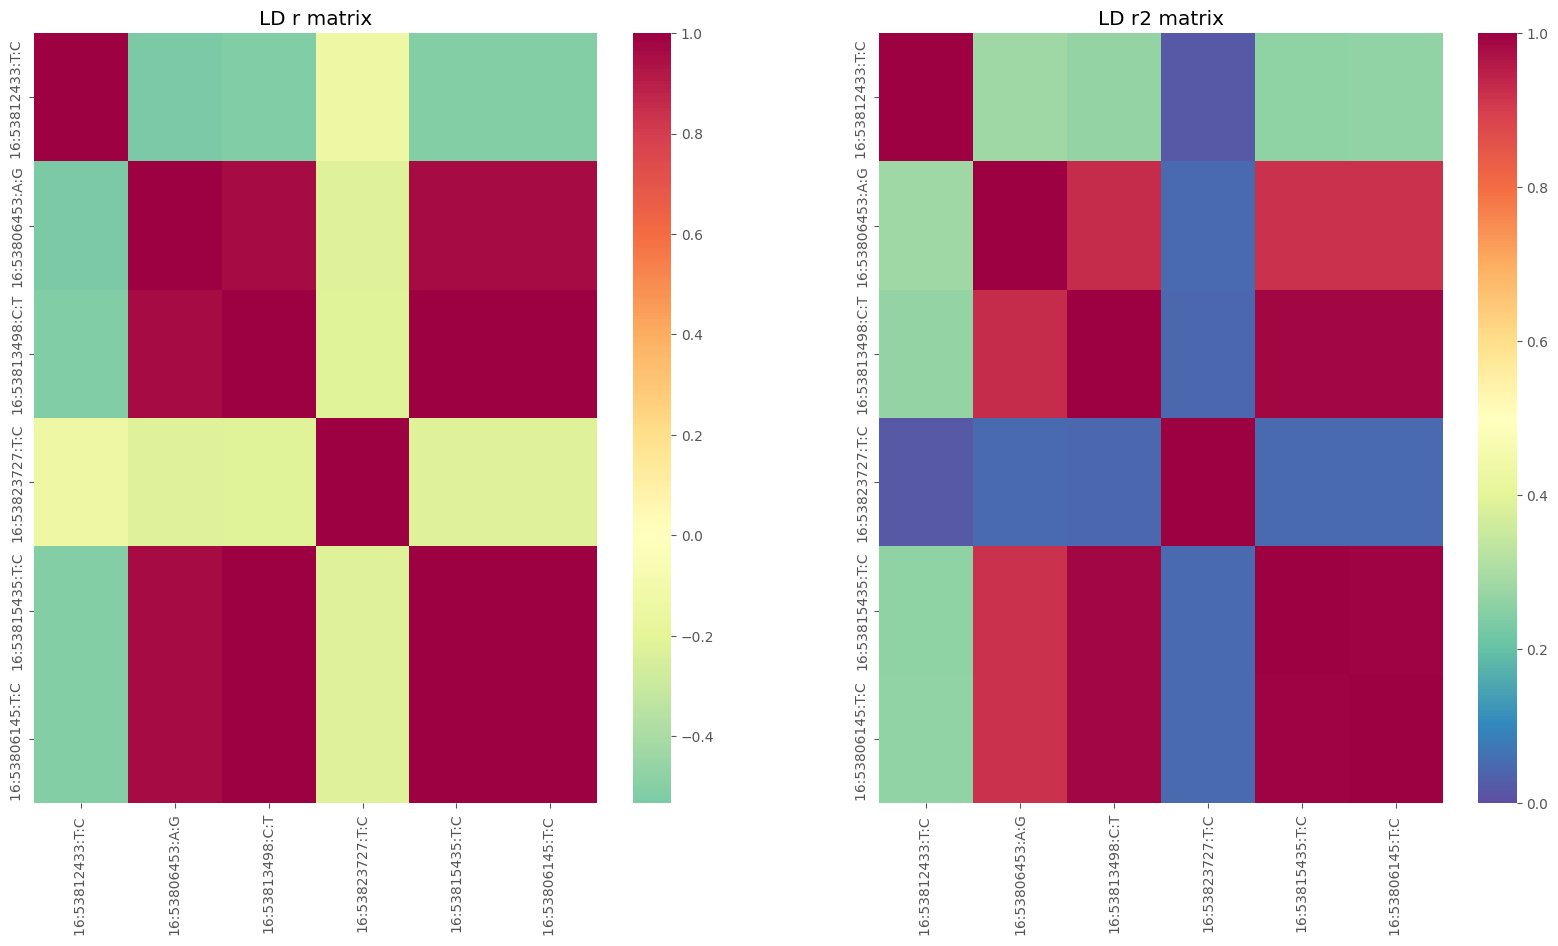

In [ ]:
plt.figure(figsize=(10,10),dpi=200)
fig, ax = plt.subplots(ncols=2,figsize=(20,10))
sns.heatmap(data=ld, cmap="Spectral_r",ax=ax[0],center=0)
sns.heatmap(data=ld2,cmap="Spectral_r",ax=ax[1],vmin=0,vmax=1)
ax[0].set_title("LD r matrix")
ax[1].set_title("LD r2 matrix")